# Clasificación de cobertura del suelo en Villa Hayes con Sentinel-2

**Proyecto final · Diplomado en Machine Learning y Deep Learning Aplicado · FIUNA**
Juan Andrés Cardozo Becvort

---

## El problema

El distrito de Villa Hayes (Presidente Hayes, Bajo Chaco) tiene **17 650 km²**. Saber qué cubre
cada parte del territorio —bosque, humedal, pastura, cultivo, ciudad, agua— es la base para
planificar, controlar el cambio de uso del suelo y evaluar impactos ambientales.

Hoy ese mapa se obtiene de dos formas, y las dos tienen un límite:

- **Fotointerpretación manual:** precisa, pero lenta y cara. Cubrir el distrito lleva semanas
  de trabajo técnico, y hay que repetirla cada vez que se quiere actualizar.
- **Productos regionales (MapBiomas):** gratuitos, pero salen una vez por año, con atraso
  (la Colección 5 llega a 2023) y a 30 m de resolución.

**Objetivo:** entrenar un clasificador que asigne una de 6 clases de cobertura a cada píxel
de 10 m de Sentinel-2, usando la dinámica estacional (temporada húmeda contra seca), y que
pueda aplicarse a cualquier año —incluido uno que MapBiomas todavía no publicó.

**Para quién:** técnicos de planificación territorial y gestión ambiental (municipalidad,
gobernación, consultoras) que necesitan un mapa actualizado sin pagar semanas de digitalización.

## Por qué Machine Learning

La relación entre 37 variables espectrales y la clase de cobertura no se puede escribir a mano.
Un umbral de NDVI separa agua de vegetación, pero no separa una pastura de un cultivo: eso
depende de cómo cambia el píxel entre temporadas, combinado con varias bandas a la vez. Un
clasificador aprende esas combinaciones a partir de ejemplos etiquetados.

## Métrica de éxito: F1-macro

El territorio está muy desbalanceado: más del 90% es bosque y el área urbana es menos del
0.1%. Con **accuracy**, un modelo que diga "bosque" siempre acertaría el 90% y sería inútil.
El **F1-macro** promedia el F1 de cada clase con el mismo peso: obliga al modelo a ser bueno
también en las clases chicas, que son justamente las de interés (cultivo, ciudad).

**Umbral de éxito:** F1-macro ≥ 0.80 en un test espacialmente independiente. Además se mide
contra un conjunto de puntos verificados a mano, para saber cuánto del resultado depende de la
calidad de las etiquetas de MapBiomas.

## Datos

| | Fuente | Detalle |
|---|---|---|
| Imágenes | Sentinel-2 SR Harmonized | 10 bandas, compuestos medianos por temporada |
| Etiquetas | MapBiomas Chaco Colección 5 | reclasificadas a 6 clases, solo píxeles en zonas homogéneas (3×3) |
| Límite | INE Paraguay | distrito de Villa Hayes |
| Años | 2019, 2021, 2023 | 500 muestras por clase y por año |

Las muestras se extrajeron en Google Earth Engine con el notebook
`extraccion/pf_nb1_extraccion_muestras.ipynb`. Ese paso necesita credenciales de Earth Engine,
así que se corrió una sola vez y su resultado quedó en `data/muestras_villa_hayes.csv`.
**Este notebook no depende de Earth Engine:** corre en cualquier máquina.

**Features (37 por píxel):** las 10 bandas y 6 índices espectrales (NDVI, NDWI, MNDWI, NDBI,
BSI, SAVI) para la temporada húmeda (dic–mar) y la seca (jun–sep), más 5 diferencias
húmeda − seca. Esas diferencias son las que separan un cultivo (cambia mucho en el año) de una
pastura (estable).

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                             ConfusionMatrixDisplay)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
SEMILLA = 42
os.makedirs("img", exist_ok=True)

NOMBRES = {1: "Bosque", 2: "Humedal", 3: "Pastura", 4: "Agricola", 6: "Urbano", 7: "Agua"}
COLORES = {1: "#1f8d49", 2: "#519799", 3: "#d6bc74", 4: "#e974ed", 6: "#54231c", 7: "#2532e4"}

## 1 · Carga de datos

Primero busca el CSV en `data/`. Si no está (por ejemplo, si se corre desde el ZIP de entrega,
que por reglamento no lleva el dataset completo), lo baja del repositorio de GitHub.

In [2]:
RUTA_LOCAL = "data/muestras_villa_hayes.csv"
URL_GITHUB = ("https://raw.githubusercontent.com/jandres998/clasificacion-cobertura-villa-hayes/"
              "main/data/muestras_villa_hayes.csv")

if os.path.exists(RUTA_LOCAL):
    df = pd.read_csv(RUTA_LOCAL)
    print("Leído desde", RUTA_LOCAL)
else:
    df = pd.read_csv(URL_GITHUB)
    print("Leído desde GitHub")

print(f"{len(df):,} filas × {df.shape[1]} columnas")
df.head()

Leído desde data/muestras_villa_hayes.csv
9,000 filas × 42 columnas


,B2_humeda,B3_humeda,B4_humeda,B5_humeda,B6_humeda,B7_humeda,B8_humeda,B8A_humeda,B11_humeda,B12_humeda,...,dNDVI,dNDWI,dMNDWI,dBSI,dSAVI,clase,bloque,anio,lon,lat
0,0.03525,0.06420,0.04935,0.10720,0.20950,0.24845,0.2564,0.27715,0.19810,0.10350,...,0.045182,-0.003858,0.013880,-0.031809,0.032773,1,884609528,2019,-57.678354,-23.576150
1,0.03090,0.05610,0.03280,0.09145,0.24580,0.29285,0.2953,0.32000,0.17795,0.07960,...,0.117715,-0.059617,0.032005,-0.136529,0.130648,1,881709535,2019,-59.130660,-23.229041
2,0.03490,0.05745,0.04360,0.10060,0.22205,0.26285,0.2470,0.29090,0.19600,0.09775,...,0.070500,-0.032866,0.040381,-0.096613,0.093573,1,881809532,2019,-59.089518,-23.377622
3,0.03740,0.06890,0.04925,0.11225,0.22705,0.26430,0.2636,0.29050,0.16645,0.08280,...,0.027194,0.002161,0.064322,-0.062886,0.035560,1,881809530,2019,-59.067060,-23.483803
4,0.02940,0.05840,0.04160,0.11290,0.22300,0.25390,0.2612,0.28860,0.20030,0.10590,...,0.105034,-0.020041,0.026182,-0.078413,0.084617,1,884209525,2019,-57.867629,-23.704160


## 2 · Exploración

Tres chequeos antes de modelar: si las clases están balanceadas en la muestra, si hay datos
faltantes y si las clases se distinguen en los índices clave.

In [3]:
FEATURES = [c for c in df.columns if c not in ["clase", "bloque", "anio", "lon", "lat"]]
print(f"Features: {len(FEATURES)}")
print(f"Faltantes: {int(df[FEATURES].isna().sum().sum())}")
print(f"Bloques espaciales: {df['bloque'].nunique()}\n")

tabla = pd.crosstab(df["clase"].map(NOMBRES), df["anio"])
tabla["total"] = tabla.sum(axis=1)
tabla

Features: 37
Faltantes: 0
Bloques espaciales: 560



anio,2019,2021,2023,total
clase,,,,
Agricola,500,500,500,1500
Agua,500,500,500,1500
Bosque,500,500,500,1500
Humedal,500,500,500,1500
Pastura,500,500,500,1500
Urbano,500,500,500,1500


In [4]:
indices = ["NDVI_humeda", "NDVI_seca", "dNDVI", "MNDWI_humeda", "NDBI_seca", "BSI_seca"]
resumen = df.groupby("clase")[indices].mean().round(3)
resumen.index = resumen.index.map(NOMBRES)
resumen

,NDVI_humeda,NDVI_seca,dNDVI,MNDWI_humeda,NDBI_seca,BSI_seca
clase,,,,,,
Bosque,0.711,0.599,0.112,-0.506,-0.066,-0.026
Humedal,0.736,0.556,0.180,-0.468,-0.078,-0.028
Pastura,0.548,0.437,0.111,-0.521,0.080,0.115
Agricola,0.652,0.232,0.420,-0.425,0.279,0.271
Urbano,0.430,0.385,0.045,-0.434,0.004,0.053
Agua,-0.451,-0.411,-0.040,0.652,-0.400,0.041


**Lectura:** el agua es inconfundible (MNDWI alto, NDVI negativo). Agrícola tiene el **dNDVI
más alto** (0.42): el cultivo está verde en la temporada húmeda y cosechado en la seca. La
pastura y el bosque son mucho más estables (dNDVI ≈ 0.11). Bosque y humedal se parecen en
casi todo: es la confusión que esperamos ver en la matriz.

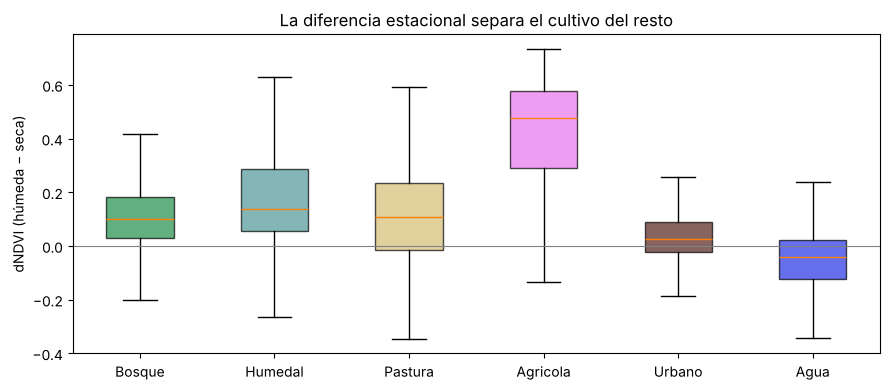

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
clases = sorted(NOMBRES)
datos = [df.loc[df["clase"] == c, "dNDVI"] for c in clases]
caja = ax.boxplot(datos, patch_artist=True, showfliers=False)
ax.set_xticks(range(1, len(clases) + 1), [NOMBRES[c] for c in clases])
for parche, c in zip(caja["boxes"], clases):
    parche.set_facecolor(COLORES[c]); parche.set_alpha(0.7)
ax.axhline(0, color="grey", lw=0.8)
ax.set_ylabel("dNDVI (húmeda − seca)")
ax.set_title("La diferencia estacional separa el cultivo del resto")
plt.tight_layout(); plt.savefig("img/dndvi_por_clase.png", dpi=120); plt.show()

## 3 · Partición espacial train / test

**Por qué no un split aleatorio.** Dos píxeles vecinos son casi idénticos. Con un split
aleatorio, uno cae en train y su vecino en test, y el modelo "acierta" porque ya vio ese
lugar: la métrica sale inflada. Es la versión espacial de "el futuro no puede entrenar al
pasado".

**Qué hacemos.** Cada muestra trae el ID de un **bloque** de ~5.5 km. Partimos por bloques
enteros con `StratifiedGroupKFold`: ningún bloque aparece en train y en test a la vez.

**Sobre el área urbana.** Casi toda la superficie urbana del distrito está en un solo bloque (la
ciudad de Villa Hayes). Para no depender del azar, de los 5 folds posibles tomamos como test el
que deja la distribución de clases más pareja. La elección mira solo la composición del test,
nunca el desempeño del modelo.

In [6]:
codigos = sorted(df["clase"].unique())
a_indice = {c: i for i, c in enumerate(codigos)}   # XGBoost exige etiquetas 0..k-1
a_codigo = {i: c for c, i in a_indice.items()}

X = df[FEATURES]
y = df["clase"].map(a_indice)
grupos = df["bloque"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
folds = list(sgkf.split(X, y, grupos))

def desbalance(idx):
    proporciones = np.bincount(y.iloc[idx], minlength=len(codigos)) / len(idx)
    return proporciones.std()

idx_train, idx_test = min(folds, key=lambda f: desbalance(f[1]))

X_train, y_train, g_train = X.iloc[idx_train], y.iloc[idx_train], grupos.iloc[idx_train]
X_test, y_test, g_test = X.iloc[idx_test], y.iloc[idx_test], grupos.iloc[idx_test]

compartidos = set(g_train) & set(g_test)
print(f"Train: {len(X_train):,} muestras en {g_train.nunique()} bloques")
print(f"Test:  {len(X_test):,} muestras en {g_test.nunique()} bloques")
print(f"Bloques compartidos entre train y test: {len(compartidos)}  (tiene que ser 0)\n")
print(pd.Series(y_test.map(a_codigo).map(NOMBRES)).value_counts().to_string())

Train: 7,210 muestras en 448 bloques
Test:  1,790 muestras en 112 bloques
Bloques compartidos entre train y test: 0  (tiene que ser 0)

clase
Bosque      300
Humedal     300
Pastura     300
Agua        300
Agricola    298
Urbano      292


## 4 · Preprocesamiento: `ColumnTransformer` + `Pipeline`

Todas las features son numéricas. El preprocesamiento imputa con la mediana (por si un píxel
quedó con hueco de nubes) y estandariza. Va **dentro** del Pipeline: así la mediana y la escala
se aprenden solo con los datos de entrenamiento de cada fold, sin filtrar información del test.

Los árboles no necesitan estandarizar, pero la regresión logística sí, y usar el mismo
preprocesamiento para todos hace la comparación justa.

In [7]:
preprocesador = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputador", SimpleImputer(strategy="median")),
            ("escalador", StandardScaler()),
        ]), FEATURES),
    ],
    verbose_feature_names_out=False,
)

def armar(modelo):
    return Pipeline([("prep", preprocesador), ("modelo", modelo)])

modelos = {
    "Dummy (baseline)": DummyClassifier(strategy="most_frequent"),
    "Regresión logística": LogisticRegression(max_iter=3000),
    "Random Forest": RandomForestClassifier(n_estimators=300, min_samples_leaf=2,
                                            n_jobs=-1, random_state=SEMILLA),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             n_jobs=-1, random_state=SEMILLA),
}
armar(modelos["XGBoost"])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. ``""{feature_name}__{transformer_name}

## 5 · Comparación de modelos con validación cruzada espacial

Cada modelo se evalúa con `StratifiedGroupKFold` de 5 folds **dentro del train** (el test no se
toca). Al lado se muestra el mismo modelo con un `StratifiedKFold` aleatorio: la diferencia
entre las dos columnas es cuánto se infla la métrica cuando se ignora la autocorrelación espacial.

In [8]:
cv_espacial = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=0)
cv_aleatorio = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

filas = []
for nombre, modelo in modelos.items():
    pipe = armar(modelo)
    t0 = time.time()
    esp = cross_val_score(pipe, X_train, y_train, groups=g_train, cv=cv_espacial,
                          scoring="f1_macro", n_jobs=1)
    seg = time.time() - t0
    ale = cross_val_score(pipe, X_train, y_train, cv=cv_aleatorio,
                          scoring="f1_macro", n_jobs=1)
    filas.append({"modelo": nombre, "F1 espacial": esp.mean(), "± desvío": esp.std(),
                  "F1 aleatorio": ale.mean(), "inflado": ale.mean() - esp.mean(),
                  "segundos": seg})
    print(f"{nombre:<22} espacial {esp.mean():.3f} ± {esp.std():.3f}   aleatorio {ale.mean():.3f}")

comparacion = pd.DataFrame(filas).sort_values("F1 espacial", ascending=False).reset_index(drop=True)
comparacion.round(3)

Dummy (baseline)       espacial 0.023 ± 0.016   aleatorio 0.048


Regresión logística    espacial 0.798 ± 0.043   aleatorio 0.872


Random Forest          espacial 0.799 ± 0.053   aleatorio 0.880


XGBoost                espacial 0.821 ± 0.049   aleatorio 0.899


,modelo,F1 espacial,± desvío,F1 aleatorio,inflado,segundos
0,XGBoost,0.821,0.049,0.899,0.078,21.210
1,Random Forest,0.799,0.053,0.880,0.081,22.043
2,Regresión logística,0.798,0.043,0.872,0.074,9.219
3,Dummy (baseline),0.023,0.016,0.048,0.025,0.376


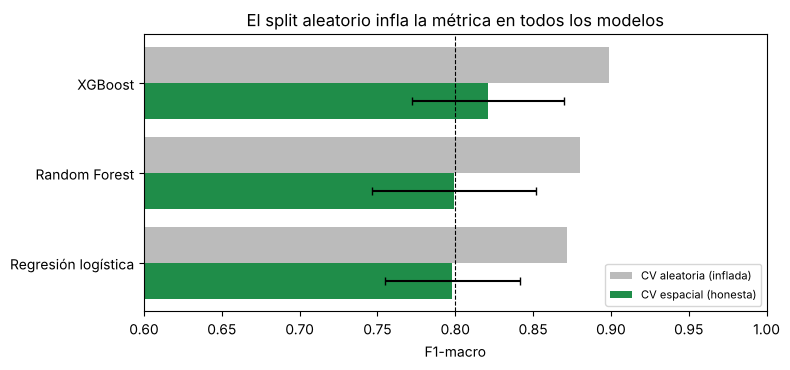

In [9]:
fig, ax = plt.subplots(figsize=(8, 3.8))
orden = comparacion[comparacion["modelo"] != "Dummy (baseline)"].iloc[::-1]
pos = np.arange(len(orden))
ax.barh(pos + 0.2, orden["F1 aleatorio"], 0.4, color="#bbbbbb", label="CV aleatoria (inflada)")
ax.barh(pos - 0.2, orden["F1 espacial"], 0.4, color="#1f8d49", label="CV espacial (honesta)",
        xerr=orden["± desvío"], capsize=3)
ax.set_yticks(pos); ax.set_yticklabels(orden["modelo"])
ax.set_xlim(0.6, 1.0); ax.set_xlabel("F1-macro")
ax.axvline(0.80, color="black", ls="--", lw=0.8)
ax.legend(loc="lower right", fontsize=8)
ax.set_title("El split aleatorio infla la métrica en todos los modelos")
plt.tight_layout(); plt.savefig("img/cv_espacial_vs_aleatoria.png", dpi=120); plt.show()

**Elección del modelo.** La regla, fijada antes de mirar resultados, es elegir el de mayor F1-macro
en la validación cruzada **espacial**. Hay un segundo criterio práctico: el modelo se entrega
dentro de un ZIP de menos de 20 MB, y un Random Forest de 300 árboles completos pesa bastante
más que un XGBoost de árboles de profundidad 5.

In [10]:
candidatos = comparacion[comparacion["modelo"] != "Dummy (baseline)"]
NOMBRE_ELEGIDO = candidatos.iloc[0]["modelo"]
print("Modelo elegido:", NOMBRE_ELEGIDO)

modelo_final = armar(modelos[NOMBRE_ELEGIDO])
t0 = time.time()
modelo_final.fit(X_train, y_train)
print(f"Entrenado en {time.time() - t0:.1f} s")

Modelo elegido: XGBoost


Entrenado en 4.7 s


## 6 · Evaluación sobre el test espacial

Primera y única vez que el modelo ve el test.

In [11]:
pred_test = modelo_final.predict(X_test)

f1_test = f1_score(y_test, pred_test, average="macro")
acc_test = accuracy_score(y_test, pred_test)
print(f"F1-macro test:  {f1_test:.3f}   (umbral de éxito: 0.80)")
print(f"Accuracy test:  {acc_test:.3f}\n")

nombres_ord = [NOMBRES[a_codigo[i]] for i in range(len(codigos))]
print(classification_report(y_test, pred_test, target_names=nombres_ord, digits=3))

F1-macro test:  0.889   (umbral de éxito: 0.80)
Accuracy test:  0.889

              precision    recall  f1-score   support

      Bosque      0.807     0.807     0.807       300
     Humedal      0.835     0.843     0.839       300
     Pastura      0.888     0.923     0.905       300
    Agricola      0.913     0.913     0.913       298
      Urbano      0.920     0.863     0.890       292
        Agua      0.977     0.987     0.982       300

    accuracy                          0.889      1790
   macro avg      0.890     0.889     0.889      1790
weighted avg      0.890     0.889     0.889      1790



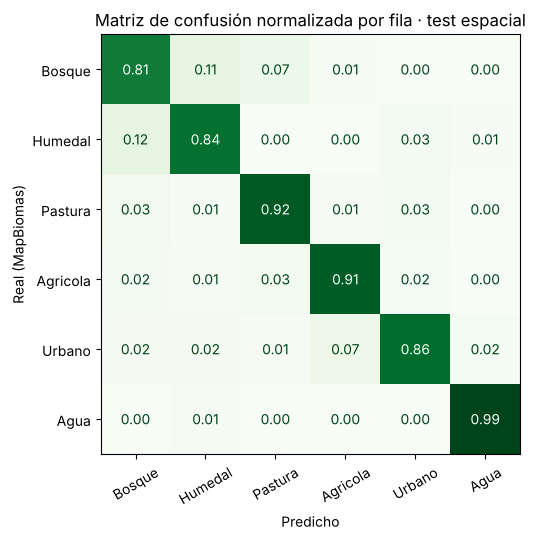

In [12]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test, display_labels=nombres_ord, normalize="true",
    values_format=".2f", cmap="Greens", ax=ax, colorbar=False)
ax.set_xlabel("Predicho"); ax.set_ylabel("Real (MapBiomas)")
ax.set_title("Matriz de confusión normalizada por fila · test espacial")
plt.xticks(rotation=30); plt.tight_layout()
plt.savefig("img/matriz_confusion.png", dpi=120); plt.show()

**Test contra validación cruzada.** El F1-macro del test (~0.89) sale más alto que el promedio
de la validación cruzada espacial (~0.82 ± 0.05). No se contradicen: entre los folds de la CV
hay uno donde la ciudad de Villa Hayes queda entera fuera del entrenamiento, y ahí el área
urbana se predice mucho peor. La CV mide el desempeño promedio, peor caso incluido; el test
mide una partición concreta. Para el informe, la cifra prudente es la de la CV.

**Cómo leer la matriz.** Cada fila suma 1: es la proporción de píxeles de esa clase real que
terminó en cada clase predicha. La diagonal es el recall por clase. Las celdas fuera de la
diagonal dicen **con qué** se confunde cada clase, y suelen tener sentido físico: humedal con
bosque (los dos son vegetación densa y húmeda en la temporada de lluvias), pastura con cultivo
y con urbano.

## 7 · Qué variables usa el modelo

Comparamos la importancia nativa del modelo (`feature_importances_`, basada en cuánto mejora
cada split) con **SHAP**, que mide cuánto mueve cada variable la predicción en cada píxel. Como
vimos en el Módulo 3, las dos no siempre coinciden. SHAP es la más confiable para interpretar.

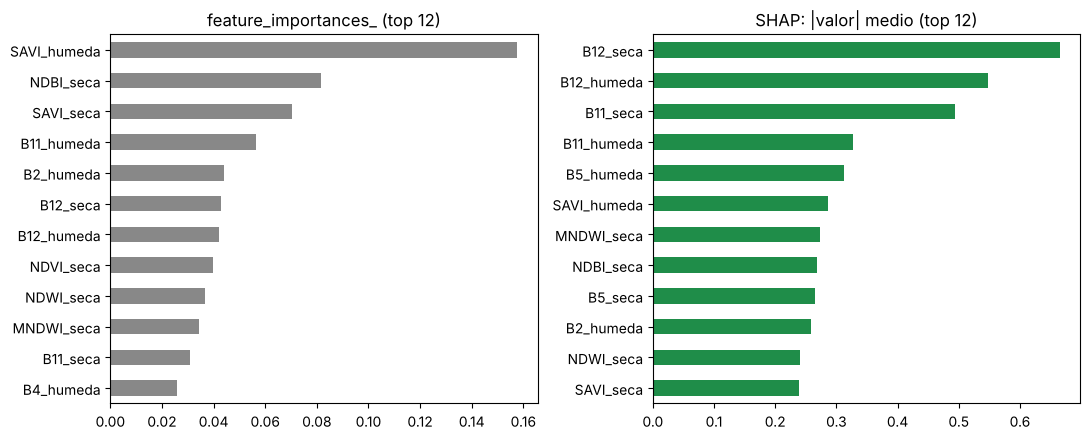

De las 10 variables más importantes, 5 son de la temporada seca o diferencias estacionales.


In [13]:
nombres_feat = modelo_final.named_steps["prep"].get_feature_names_out()
importancia = pd.Series(modelo_final.named_steps["modelo"].feature_importances_,
                        index=nombres_feat).sort_values(ascending=False)

try:
    import shap
    muestra = X_test.sample(400, random_state=SEMILLA)
    Xm = pd.DataFrame(modelo_final.named_steps["prep"].transform(muestra), columns=nombres_feat)
    valores = shap.TreeExplainer(modelo_final.named_steps["modelo"]).shap_values(Xm)
    valores = np.array(valores)
    if valores.ndim == 3 and valores.shape[0] == len(codigos):   # (clases, filas, features)
        valores = np.moveaxis(valores, 0, -1)
    imp_shap = pd.Series(np.abs(valores).mean(axis=(0, 2)), index=nombres_feat)
    imp_shap = imp_shap.sort_values(ascending=False)
except Exception as e:
    print("SHAP no disponible:", type(e).__name__)
    imp_shap = None

fig, axes = plt.subplots(1, 2 if imp_shap is not None else 1, figsize=(11, 4.5))
axes = np.atleast_1d(axes)
importancia.head(12).iloc[::-1].plot.barh(ax=axes[0], color="#888888")
axes[0].set_title("feature_importances_ (top 12)")
if imp_shap is not None:
    imp_shap.head(12).iloc[::-1].plot.barh(ax=axes[1], color="#1f8d49")
    axes[1].set_title("SHAP: |valor| medio (top 12)")
plt.tight_layout(); plt.savefig("img/importancia_variables.png", dpi=120); plt.show()

n_estacionales = sum(1 for f in (imp_shap if imp_shap is not None else importancia).head(10).index
                     if f.startswith("d") or f.endswith("_seca"))
print(f"De las 10 variables más importantes, {n_estacionales} son de la temporada seca o diferencias estacionales.")

## 8 · Validación independiente con puntos verificados a mano

El test anterior sigue usando etiquetas de MapBiomas, que tienen sus propios errores. Para una
métrica que no herede esos errores, se reservó 1 de cada 5 bloques **fuera del muestreo de
entrenamiento**, se tomaron puntos candidatos en esos bloques y se verificó cada uno a mano sobre
imagen de alta resolución (año 2023).

Si el archivo de puntos verificados no está, la sección se salta sin romper el notebook.

In [14]:
RUTA_VAL = "data/validacion_verificada.csv"
URL_VAL = URL_GITHUB.replace("muestras_villa_hayes.csv", "validacion_verificada.csv")

try:
    val = pd.read_csv(RUTA_VAL if os.path.exists(RUTA_VAL) else URL_VAL)
    hay_validacion = True
except Exception:
    hay_validacion = False

if hay_validacion:
    val = val[pd.to_numeric(val["clase_verificada"], errors="coerce").notna()].copy()
    val["clase_verificada"] = val["clase_verificada"].astype(int)
    val = val[val["clase_verificada"].isin(codigos)]

    real_val = val["clase_verificada"].values
    pred_val = pd.Series(modelo_final.predict(val[FEATURES])).map(a_codigo).values
    mb_val = val["clase_mapbiomas"].values

    # Intervalo de confianza por bootstrap: con ~100 puntos la incertidumbre es grande,
    # y hay que mostrarla junto con la cifra.
    rng = np.random.default_rng(SEMILLA)
    n = len(real_val)
    boot_mod, boot_mb = [], []
    for _ in range(2000):
        i = rng.integers(0, n, n)
        boot_mod.append(accuracy_score(real_val[i], pred_val[i]))
        boot_mb.append(accuracy_score(real_val[i], mb_val[i]))
    ic = lambda b: np.percentile(b, [2.5, 97.5])
    dif = np.array(boot_mod) - np.array(boot_mb)

    sin_urbano = [c for c in codigos if c != 6]
    print(f"Puntos verificados: {n}\n")
    print(f"{'':32s}{'Modelo':>10s}{'MapBiomas':>12s}")
    print(f"{'Accuracy':32s}{accuracy_score(real_val, pred_val):>10.3f}{accuracy_score(real_val, mb_val):>12.3f}")
    print(f"{'  IC 95% (bootstrap)':32s}{str(ic(boot_mod).round(2)):>10s}{str(ic(boot_mb).round(2)):>12s}")
    print(f"{'F1-macro (6 clases)':32s}{f1_score(real_val, pred_val, average='macro'):>10.3f}"
          f"{f1_score(real_val, mb_val, average='macro'):>12.3f}")
    print(f"{'F1-macro sin Urbano (5 clases)':32s}"
          f"{f1_score(real_val, pred_val, labels=sin_urbano, average='macro'):>10.3f}"
          f"{f1_score(real_val, mb_val, labels=sin_urbano, average='macro'):>12.3f}")
    print(f"\nDiferencia de accuracy modelo − MapBiomas: {dif.mean():+.3f}  IC 95% {ic(dif).round(3)}")
    print(f"Coincidencia modelo ↔ MapBiomas en estos puntos: {(pred_val == mb_val).mean():.0%}\n")

    presentes = sorted(set(real_val) | set(pred_val))
    print(classification_report(real_val, pred_val, labels=presentes,
                                target_names=[NOMBRES[c] for c in presentes],
                                digits=3, zero_division=0))
else:
    print("No hay archivo de validación verificada: sección omitida.")

Puntos verificados: 110

                                    Modelo   MapBiomas
Accuracy                             0.718       0.745
  IC 95% (bootstrap)            [0.64 0.8 ] [0.67 0.83]
F1-macro (6 clases)                  0.653       0.672
F1-macro sin Urbano (5 clases)       0.744       0.770

Diferencia de accuracy modelo − MapBiomas: -0.027  IC 95% [-0.082  0.018]
Coincidencia modelo ↔ MapBiomas en estos puntos: 87%

              precision    recall  f1-score   support

      Bosque      0.600     0.682     0.638        22
     Humedal      1.000     0.565     0.722        23
     Pastura      0.478     0.647     0.550        17
    Agricola      1.000     0.714     0.833        28
      Urbano      0.111     1.000     0.200         1
        Agua      0.950     1.000     0.974        19

    accuracy                          0.718       110
   macro avg      0.690     0.768     0.653       110
weighted avg      0.823     0.718     0.746       110



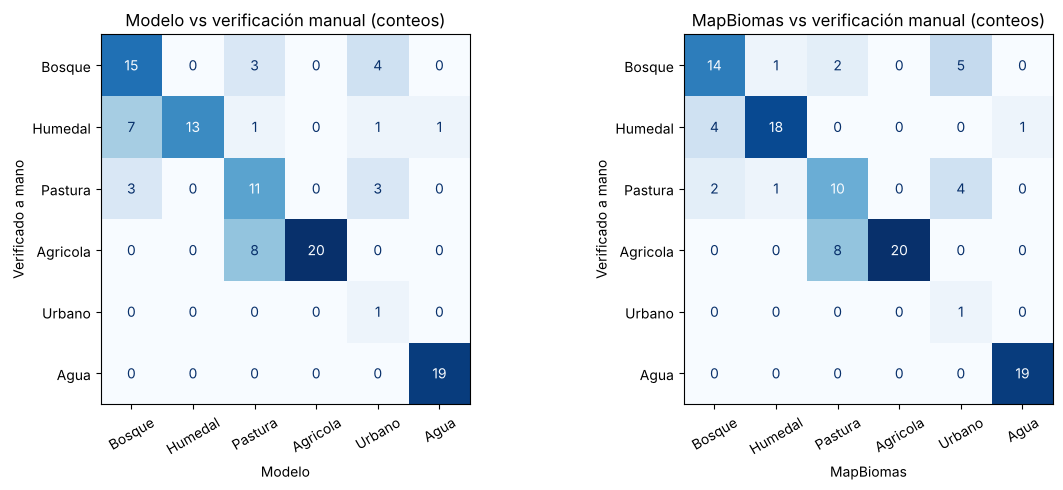

In [15]:
if hay_validacion:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    etiquetas = [NOMBRES[c] for c in codigos]
    for ax, pred, titulo in [(axes[0], pred_val, "Modelo"), (axes[1], mb_val, "MapBiomas")]:
        ConfusionMatrixDisplay.from_predictions(
            real_val, pred, labels=codigos, display_labels=etiquetas,
            cmap="Blues", ax=ax, colorbar=False)
        ax.set_title(f"{titulo} vs verificación manual (conteos)")
        ax.set_xlabel(titulo); ax.set_ylabel("Verificado a mano")
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout(); plt.savefig("img/validacion_manual.png", dpi=120); plt.show()

**Lectura de la validación independiente.** Es el resultado más importante del trabajo, y no es
el mismo que el del test:

- **Contra la verificación manual, el modelo no llega al umbral de 0.80.** El F1-macro de 6
  clases es 0.65, pero ese número está dominado por Urbano, que tiene **un solo punto**
  verificado: no se puede evaluar. Sin Urbano, el F1-macro es 0.74 y la accuracy 0.72
  (IC 95% ≈ 0.64–0.80).
- **El modelo rinde igual que su propia fuente de etiquetas.** MapBiomas obtiene 0.75 de
  accuracy contra los mismos puntos, y la diferencia con el modelo (−0.03) tiene un intervalo de
  confianza que incluye el cero. El modelo coincide con MapBiomas en el 87% de los puntos:
  **aprendió MapBiomas, con sus errores incluidos.**
- **Los errores compartidos son los de la etiqueta.** De los 20 puntos que MapBiomas llama
  pastura, 8 se verificaron como cultivo, y el modelo los clasifica igual que MapBiomas. Lo mismo
  pasa con los 10 puntos "urbanos" de MapBiomas: 9 eran bosque o pastura (probablemente cascos de
  estancia o poblados chicos), y el modelo los marca urbanos.
- **Dónde el modelo sí falla por cuenta propia:** humedal verificado que predice como bosque
  (7 de 23). Es la confusión que ya aparecía en el test.

La conclusión honesta es que **el techo de este modelo lo pone la calidad de las etiquetas, no el
algoritmo.** Con etiquetas de MapBiomas se obtiene un mapa equivalente a MapBiomas, pero a 10 m y
aplicable a años que MapBiomas no cubre. Para superarlo hace falta entrenar con etiquetas mejores
(por ejemplo, estos mismos puntos verificados, ampliados).

## 9 · Guardar el modelo y probar la inferencia

Se guarda el Pipeline completo (preprocesamiento + modelo) junto con la lista de features y el
mapa de clases. Así, quien lo cargue no necesita reconstruir nada: le pasa una tabla con las 37
columnas y obtiene la clase.

In [16]:
paquete = {
    "pipeline": modelo_final,
    "features": FEATURES,
    "a_codigo": a_codigo,
    "nombres": NOMBRES,
    "colores": COLORES,
    "modelo": NOMBRE_ELEGIDO,
    "metricas": {"f1_macro_test": round(f1_test, 4), "accuracy_test": round(acc_test, 4)},
}
joblib.dump(paquete, "model.pkl", compress=3)
print(f"model.pkl guardado: {os.path.getsize('model.pkl') / 1e6:.2f} MB")

model.pkl guardado: 1.10 MB


In [17]:
# Prueba de punta a punta: cargar el archivo como lo haría la app y predecir.
cargado = joblib.load("model.pkl")
ejemplo = X_test.sample(5, random_state=1)
pred = pd.Series(cargado["pipeline"].predict(ejemplo[cargado["features"]])).map(cargado["a_codigo"])
proba = cargado["pipeline"].predict_proba(ejemplo[cargado["features"]]).max(axis=1)

pd.DataFrame({
    "real (MapBiomas)": y_test.loc[ejemplo.index].map(a_codigo).map(NOMBRES).values,
    "predicho": pred.map(NOMBRES).values,
    "confianza": proba.round(3),
})

,real (MapBiomas),predicho,confianza
0,Bosque,Bosque,0.994
1,Bosque,Bosque,0.996
2,Humedal,Humedal,0.950
3,Humedal,Humedal,0.826
4,Humedal,Humedal,0.733


## 10 · Muestra de 100 filas para la entrega

Sale del **test** (datos que el modelo no vio al entrenar), con la misma cantidad por clase.
La app de Streamlit usa este archivo como ejemplo de entrada.

In [18]:
test_df = df.iloc[idx_test]
por_clase = 100 // len(codigos)
muestra_100 = pd.concat([g.sample(min(len(g), por_clase), random_state=SEMILLA)
                         for _, g in test_df.groupby("clase")])
resto = 100 - len(muestra_100)
if resto > 0:
    muestra_100 = pd.concat([muestra_100,
                             test_df.drop(muestra_100.index).sample(resto, random_state=SEMILLA)])
muestra_100 = muestra_100.sample(frac=1, random_state=SEMILLA).reset_index(drop=True)
muestra_100.to_csv("datos_muestra.csv", index=False)
print(f"datos_muestra.csv: {len(muestra_100)} filas")
print(muestra_100["clase"].map(NOMBRES).value_counts().to_string())

datos_muestra.csv: 100 filas
clase
Agua        17
Agricola    17
Urbano      17
Bosque      17
Pastura     16
Humedal     16


## 11 · Retorno de la inversión (ROI)

Comparación del costo de producir el mapa de cobertura del distrito por fotointerpretación
manual contra este pipeline, en tres escenarios de frecuencia de actualización.

Supuestos: tarifa de 30 USD/h y 40 segundos por km² de interpretación más digitalización
manual (un promedio entre zonas rurales homogéneas, que se resuelven rápido, y zonas mixtas que
llevan más tiempo). Las horas de desarrollo son la inversión única de construir el pipeline.

In [19]:
AREA_KM2 = 17650

# --- Supuestos (ajustar) ---
TARIFA_HORA = 30            # USD por hora de técnico SIG
SEG_POR_KM2 = 40            # interpretación + digitalización manual, segundos por km²
HORAS_DESARROLLO = 60       # inversión única: extracción, modelo, app, validación
HORAS_POR_MAPA_ML = 6       # por cada mapa nuevo: correr el pipeline y revisar el resultado

escenarios = {"A · Mapa único": 1, "B · Anual (5 años)": 5, "C · Trimestral (5 años)": 20}

filas = []
for nombre, n_mapas in escenarios.items():
    horas_manual = AREA_KM2 * SEG_POR_KM2 / 3600
    manual = n_mapas * horas_manual * TARIFA_HORA
    ml = (HORAS_DESARROLLO + n_mapas * HORAS_POR_MAPA_ML) * TARIFA_HORA
    filas.append({"escenario": nombre, "mapas": n_mapas,
                  "costo manual (USD)": round(manual), "costo ML (USD)": round(ml),
                  "ahorro (USD)": round(manual - ml),
                  "ROI": f"{(manual - ml) / ml:.0%}"})

roi = pd.DataFrame(filas)
print(f"Un mapa manual del distrito: {AREA_KM2 * SEG_POR_KM2 / 3600:.0f} h de trabajo\n")
roi

Un mapa manual del distrito: 196 h de trabajo



,escenario,mapas,costo manual (USD),costo ML (USD),ahorro (USD),ROI
0,A · Mapa único,1,5883,1980,3903,197%
1,B · Anual (5 años),5,29417,2700,26717,990%
2,C · Trimestral (5 años),20,117667,5400,112267,2079%


**Lectura.** Incluso con un solo mapa, el pipeline se paga, porque la inversión inicial es
menor que el costo de fotointerpretar todo el distrito una vez. El retorno crece con la
frecuencia: el costo manual escala linealmente con cada mapa, mientras que el del modelo es
casi todo fijo. A cambio, el mapa automático tiene un error medible (secciones 6 y 8), del orden del
de MapBiomas, que un técnico tiene que revisar en las zonas críticas.

## 12 · Conclusiones

- **Las dos temporadas aportan.** Entre las variables más importantes según SHAP hay de la
  temporada húmeda y de la seca, y en la exploración el dNDVI separa claramente el cultivo
  (0.42) del resto. Una sola fecha pierde esa información.
- **Las bandas SWIR (B11, B12) son las que más pesan.** Son sensibles al contenido de agua del
  suelo y de la vegetación: justamente lo que distingue humedal, bosque, pastura y ciudad en el
  Bajo Chaco.
- La **validación espacial** es imprescindible. El split aleatorio infla el F1-macro en todos
  los modelos, porque píxeles vecinos comparten casi la misma firma.
- **Limitaciones:** las etiquetas de entrenamiento vienen de MapBiomas (30 m), con sus propios
  errores. El área urbana está concentrada en muy pocos bloques. La clase "suelo desnudo"
  no existe en el distrito según MapBiomas y se descartó.

## 13 · Próximos pasos

1. Aplicar el modelo al año **2025**, que MapBiomas todavía no cubre, y cuantificar la
   conversión de bosque a pastura y cultivo entre 2019 y 2025.
2. Agregar datos de radar (Sentinel-1), que no dependen de las nubes y ayudan a separar
   humedal de bosque.
3. Usar los puntos verificados a mano (ampliados) **como etiquetas de entrenamiento**, no solo
   de validación. Es la única vía para que el modelo supere a MapBiomas en vez de imitarlo,
   sobre todo en la confusión pastura ↔ cultivo.